<a href="https://colab.research.google.com/github/psheetalreddy/XAI-Based-Retinal-Disease-Classification-using-Fine-Tuned-ResNet50-with-Grad-CAM/blob/main/4_ClinicalBERT_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 5: ClinicalBERT-Enhanced Retinal Disease Diagnosis Dashboard

This notebook extends the ResNet50 + Grad-CAM pipeline with:
- **ClinicalBERT** for semantic clinical alignment scoring
- **Structured report generation** grounded in clinical language
- **Interactive Gradio dashboard** with full visualization

### Architecture:
```
Retinal Image
     ↓
ResNet50 (fine-tuned)  →  Disease Prediction + Confidence
     ↓
Grad-CAM               →  Visual Explanation Heatmap
     ↓
Template Explanation   →  Base Clinical Text
     ↓
ClinicalBERT           →  Clinical Alignment Score (semantic grounding)
     ↓
Final Dashboard        →  Unified Report
```

## 1. Install Dependencies

In [ ]:
!pip install transformers torch gradio scikit-learn matplotlib pillow opencv-python-headless -q

## 2. Imports & Mount Drive

In [ ]:
import os
import cv2
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import gradio as gr
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
print('All imports successful.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports successful.


## 3. Configuration

In [ ]:
# ── Paths ──────────────────────────────────────────────────────────────────
MODEL_PATH    = 'drive/MyDrive/Projects/Mini-project/models/phase2_best.keras'
CAT_JSON_PATH = 'drive/MyDrive/Projects/Mini-project/eye-disease-dataset/cat_to_name.json'

# ── Model config ───────────────────────────────────────────────────────────
IMG_SIZE        = 224
LAST_CONV_LAYER = 'conv5_block3_out'

# ── ClinicalBERT config ────────────────────────────────────────────────────
BERT_MODEL_NAME = 'medicalai/ClinicalBERT'

# ── Clinical reference corpus (domain knowledge anchors) ──────────────────
# These ground the ClinicalBERT similarity in real ophthalmology language
CLINICAL_REFERENCES = {
    'cataract': (
        'Lens opacity clouding causing visual impairment. '
        'Characterized by light scattering reduced contrast sensitivity '
        'and progressive blurring of vision. Surgical intervention with '
        'phacoemulsification and intraocular lens implantation is standard care.'
    ),
    'diabetic_retinopathy': (
        'Microaneurysms dot and blot hemorrhages hard exudates cotton wool spots '
        'neovascularization venous beading macular edema. Diabetic retinopathy '
        'results from chronic hyperglycemia causing retinal vascular damage. '
        'Anti-VEGF therapy and laser photocoagulation are treatment options.'
    ),
    'glaucoma': (
        'Optic nerve damage elevated intraocular pressure cupping of optic disc '
        'increased cup-to-disc ratio peripheral vision loss visual field defects. '
        'Glaucoma is a progressive optic neuropathy. IOP-lowering therapy '
        'including prostaglandin analogues beta-blockers or surgical trabeculectomy.'
    ),
    'normal': (
        'Healthy fundus clear retinal vasculature normal optic disc '
        'sharp foveal reflex no hemorrhages no exudates no signs of pathology. '
        'Cup-to-disc ratio within normal limits macula intact.'
    )
}

# ── Severity weighting per disease ────────────────────────────────────────
DISEASE_WEIGHTS = {
    'normal': 0.10, 'cataract': 0.45,
    'diabetic_retinopathy': 0.80, 'glaucoma': 0.70
}

print('Configuration set.')

Configuration set.


## 4. Load ResNet50 Model

In [ ]:
resnet_model = load_model(MODEL_PATH)
print('ResNet50 loaded.')

with open(CAT_JSON_PATH, 'r') as f:
    class_mapping = {int(k): v for k, v in json.load(f).items()}
print(f'Class mapping: {class_mapping}')

ResNet50 loaded.
Class mapping: {1: 'cataract', 2: 'diabetic_retinopathy', 3: 'glaucoma', 4: 'normal'}


## 5. Load ClinicalBERT

ClinicalBERT is a BERT model pre-trained on clinical notes (MIMIC-III corpus).
We use it to compute **semantic similarity** between generated explanations
and established clinical reference descriptions — providing a grounded
alignment score that pure confidence metrics cannot offer.

In [ ]:
print('Loading ClinicalBERT... (first run downloads ~440 MB)')
t0 = time.time()

bert_tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model     = AutoModel.from_pretrained(BERT_MODEL_NAME)
bert_model.eval()

print(f'ClinicalBERT loaded in {time.time()-t0:.1f}s')

# Pre-compute reference embeddings once (efficiency)
def get_bert_embedding(text: str) -> np.ndarray:
    """Return [CLS] token embedding from ClinicalBERT."""
    inputs = bert_tokenizer(
        text, return_tensors='pt',
        truncation=True, max_length=256, padding=True
    )
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[:, 0, :].numpy()

print('Pre-computing reference embeddings...')
REFERENCE_EMBEDDINGS = {
    label: get_bert_embedding(text)
    for label, text in CLINICAL_REFERENCES.items()
}
print('Reference embeddings ready.')

Loading ClinicalBERT... (first run downloads ~440 MB)


config.json:   0%|          | 0.00/466 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/62.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/542M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/542M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: medicalai/ClinicalBERT
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.weight  | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


ClinicalBERT loaded in 17.4s
Pre-computing reference embeddings...
Reference embeddings ready.


## 6. Core Pipeline Functions

In [ ]:
import os
import cv2
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.resnet50 import preprocess_input
from PIL import Image
import torch
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity
import gradio as gr
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')
print('All imports successful.')

# ── Image preprocessing ────────────────────────────────────────────────────
def load_and_preprocess_image(img_path, target_size=(IMG_SIZE, IMG_SIZE)):
    img        = image.load_img(img_path, target_size=target_size)
    img_array  = image.img_to_array(img)
    original   = img_array.astype('uint8')
    img_array  = preprocess_input(np.expand_dims(img_array, axis=0))
    return original, img_array


# ── Disease prediction ─────────────────────────────────────────────────────
def predict_disease(img_array):
    preds     = resnet_model.predict(img_array, verbose=0)[0]
    pred_idx  = np.argmax(preds) + 1
    pred_label = class_mapping[pred_idx]
    confidence = float(np.max(preds))
    return pred_idx, pred_label, confidence, preds


# ── Grad-CAM ───────────────────────────────────────────────────────────────
def make_gradcam_heatmap(img_array):
    grad_model = tf.keras.models.Model(
        inputs=resnet_model.inputs,
        outputs=[resnet_model.get_layer(LAST_CONV_LAYER).output,
                 resnet_model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        # Ensure predictions[0] is the actual prediction tensor, and get class index
        pred_index   = tf.argmax(predictions[0][0])
        # Access the class channel from the actual prediction tensor
        class_channel = predictions[0][:, pred_index]
    grads       = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0.0)
    max_val      = tf.reduce_max(heatmap)
    if max_val != 0:
        heatmap /= max_val
    return heatmap.numpy()


def overlay_heatmap(original_img, heatmap, alpha=0.4):
    heatmap_resized = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap_uint8   = np.uint8(255 * heatmap_resized)
    heatmap_color   = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
    original_bgr    = cv2.cvtColor(original_img.astype('uint8'), cv2.COLOR_RGB2BGR)
    superimposed    = cv2.addWeighted(original_bgr, 1-alpha, heatmap_color, alpha, 0)
    return cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)


# ── Severity estimation ────────────────────────────────────────────────────
def estimate_severity(pred_label, confidence, heatmap):
    active_pixels = np.sum(heatmap > 0.6)
    attention_conc = active_pixels / heatmap.size
    disease_weight = DISEASE_WEIGHTS.get(pred_label, 0.50)
    severity_score = (50 * confidence + 30 * disease_weight + 20 * attention_conc) * 100 / 100
    severity_score = float(np.clip(severity_score, 0, 100))
    if severity_score < 30:   severity_level = 'Low'
    elif severity_score < 55: severity_level = 'Moderate'
    elif severity_score < 75: severity_level = 'High'
    else:                     severity_level = 'Very High'
    return round(severity_score, 2), severity_level, attention_conc


print('Core pipeline functions defined.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
All imports successful.
Core pipeline functions defined.


## 7. ClinicalBERT Alignment Module

### Why this matters academically:
Standard confidence scores tell us *how sure* the model is — but not *whether*
the model's reasoning aligns with clinical language. ClinicalBERT, trained on
MIMIC-III clinical notes, encodes domain-specific medical semantics.

The **Clinical Alignment Score** (cosine similarity between explanation
embedding and reference embedding) quantifies semantic grounding.
A high score means the model's explanation language matches established
clinical descriptions for that condition.

In [ ]:
def generate_base_explanation(pred_label, confidence, severity_score,
                               severity_level, attention_conc, probabilities):
    """Generate structured clinical explanation text."""
    conf_pct  = round(confidence * 100, 2)
    attn_pct  = round(attention_conc * 100, 2)

    conf_desc = ('very strong' if confidence > 0.85 else
                 'strong'      if confidence > 0.70 else
                 'moderate'    if confidence > 0.55 else 'uncertain')

    attn_desc = ('highly localised abnormal regions'     if attention_conc > 0.20 else
                 'moderately focused pathological regions' if attention_conc > 0.10 else
                 'diffuse or weakly localised regions')

    # Second-highest prediction for differential context
    sorted_idx = np.argsort(probabilities)[::-1]
    second_label = class_mapping.get(sorted_idx[1]+1, 'unknown')
    second_conf  = probabilities[sorted_idx[1]]

    text = (
        f'Retinal analysis indicates {pred_label} with {conf_pct}% confidence '
        f'({conf_desc} classification signal). '
        f'Grad-CAM attention map reveals {attn_desc}, '
        f'consistent with clinically relevant retinal features associated with {pred_label}. '
        f'Estimated severity proxy score is {severity_score}/100 ({severity_level} severity). '
        f'Differential consideration: {second_label} ({second_conf*100:.1f}% probability). '
        f'Clinical validation by an ophthalmologist is recommended before any treatment decision.'
    )
    return text


def compute_clinical_alignment(pred_label: str, explanation_text: str) -> dict:
    """
    Compute ClinicalBERT-based semantic alignment scores.

    Returns:
        dict with:
          - primary_score    : cosine similarity vs. predicted label's reference
          - all_scores       : similarity vs. all disease references
          - interpretation   : human-readable interpretation
    """
    exp_embedding = get_bert_embedding(explanation_text)

    all_scores = {}
    for label, ref_emb in REFERENCE_EMBEDDINGS.items():
        sim = cosine_similarity(exp_embedding, ref_emb)[0][0]
        all_scores[label] = round(float(sim), 4)

    primary_score = all_scores.get(pred_label, 0.0)

    # Rank: is predicted label the highest similarity?
    sorted_labels = sorted(all_scores, key=all_scores.get, reverse=True)
    rank = sorted_labels.index(pred_label) + 1

    if primary_score > 0.90:
        interp = 'Excellent — explanation strongly aligned with clinical literature.'
    elif primary_score > 0.80:
        interp = 'Good — explanation moderately aligned with clinical terminology.'
    elif primary_score > 0.70:
        interp = 'Fair — partial alignment; explanation uses some clinical language.'
    else:
        interp = 'Low — explanation diverges from standard clinical descriptions.'

    return {
        'primary_score' : primary_score,
        'all_scores'    : all_scores,
        'rank'          : rank,
        'interpretation': interp
    }


print('ClinicalBERT alignment module defined.')

ClinicalBERT alignment module defined.


## 8. Full Diagnosis Pipeline

In [ ]:
def run_full_diagnosis(img_path: str) -> dict:
    """
    End-to-end diagnosis pipeline:
    preprocessing → classification → Grad-CAM →
    severity → explanation → ClinicalBERT alignment
    """
    # 1. Preprocessing
    original_img, img_array = load_and_preprocess_image(img_path)

    # 2. Prediction
    pred_idx, pred_label, confidence, probabilities = predict_disease(img_array)

    # 3. Grad-CAM
    heatmap     = make_gradcam_heatmap(img_array)
    overlay_img = overlay_heatmap(original_img, heatmap)

    # 4. Severity
    severity_score, severity_level, attention_conc = estimate_severity(
        pred_label, confidence, heatmap
    )

    # 5. Base explanation
    explanation = generate_base_explanation(
        pred_label, confidence, severity_score,
        severity_level, attention_conc, probabilities
    )

    # 6. ClinicalBERT alignment scoring
    alignment = compute_clinical_alignment(pred_label, explanation)

    return {
        'pred_label'      : pred_label,
        'confidence'      : confidence,
        'probabilities'   : probabilities,
        'severity_score'  : severity_score,
        'severity_level'  : severity_level,
        'attention_conc'  : attention_conc,
        'heatmap'         : heatmap,
        'original_img'    : original_img,
        'overlay_img'     : overlay_img,
        'explanation'     : explanation,
        'alignment'       : alignment
    }


print('Full diagnosis pipeline ready.')

Full diagnosis pipeline ready.


## 9. Dashboard Visualisation Builder

In [ ]:
SEVERITY_COLORS = {
    'Low': '#2ecc71', 'Moderate': '#f39c12',
    'High': '#e67e22', 'Very High': '#e74c3c'
}
DISEASE_COLORS = {
    'cataract': '#3498db', 'diabetic_retinopathy': '#e74c3c',
    'glaucoma': '#9b59b6', 'normal': '#2ecc71'
}


def build_dashboard_figure(results: dict) -> plt.Figure:
    """
    Build a comprehensive 6-panel clinical dashboard figure.

    Panels:
      [A] Original retinal image
      [B] Grad-CAM overlay
      [C] Probability bar chart (all classes)
      [D] ClinicalBERT alignment radar/bar
      [E] Severity gauge
      [F] Structured text report
    """
    fig = plt.figure(figsize=(20, 14), facecolor='#0d1117')
    fig.patch.set_facecolor('#0d1117')

    gs = gridspec.GridSpec(
        3, 4,
        figure=fig,
        hspace=0.45, wspace=0.35,
        left=0.05, right=0.97, top=0.92, bottom=0.06
    )

    TEXT_COLOR   = '#e8eaf0'
    ACCENT_COLOR = '#58a6ff'
    PANEL_BG     = '#161b22'

    pred   = results['pred_label']
    conf   = results['confidence']
    probs  = results['probabilities']
    sev_sc = results['severity_score']
    sev_lv = results['severity_level']
    align  = results['alignment']
    expl   = results['explanation']
    attn   = results['attention_conc']

    d_color = DISEASE_COLORS.get(pred, '#58a6ff')
    s_color = SEVERITY_COLORS.get(sev_lv, '#e67e22')

    # ── Header ─────────────────────────────────────────────────────────────
    fig.text(0.5, 0.965, 'RETINAL DISEASE DIAGNOSIS REPORT',
             ha='center', va='top', fontsize=17, fontweight='bold',
             color=TEXT_COLOR, fontfamily='monospace')
    fig.text(0.5, 0.945,
             f'Prediction: {pred.upper().replace("_"," ")}   |   '
             f'Confidence: {conf*100:.1f}%   |   '
             f'Severity: {sev_lv}   |   '
             f'ClinicalBERT Alignment: {align["primary_score"]:.3f}',
             ha='center', va='top', fontsize=11, color=d_color,
             fontfamily='monospace')

    def style_ax(ax, title=''):
        ax.set_facecolor(PANEL_BG)
        for spine in ax.spines.values():
            spine.set_edgecolor('#30363d')
            spine.set_linewidth(1.2)
        if title:
            ax.set_title(title, color=ACCENT_COLOR, fontsize=10,
                         fontweight='bold', pad=8, fontfamily='monospace')
        ax.tick_params(colors=TEXT_COLOR, labelsize=8)

    # ── Panel A: Original image ────────────────────────────────────────────
    ax_a = fig.add_subplot(gs[0, 0])
    ax_a.imshow(results['original_img'].astype('uint8'))
    ax_a.axis('off')
    style_ax(ax_a, 'A  ORIGINAL FUNDUS IMAGE')

    # ── Panel B: Grad-CAM ──────────────────────────────────────────────────
    ax_b = fig.add_subplot(gs[0, 1])
    ax_b.imshow(results['overlay_img'])
    ax_b.axis('off')
    style_ax(ax_b, 'B  GRAD-CAM ATTENTION MAP')
    ax_b.text(0.5, -0.06,
              f'Attention concentration: {attn*100:.1f}%',
              ha='center', transform=ax_b.transAxes,
              color=TEXT_COLOR, fontsize=8, fontfamily='monospace')

    # ── Panel C: Probability distribution ─────────────────────────────────
    ax_c = fig.add_subplot(gs[0, 2])
    style_ax(ax_c, 'C  CLASS PROBABILITY DISTRIBUTION')
    labels = [class_mapping[i+1].replace('_', '\n') for i in range(len(probs))]
    colors_bars = [
        DISEASE_COLORS.get(class_mapping[i+1], '#58a6ff')
        for i in range(len(probs))
    ]
    bars = ax_c.barh(labels, probs, color=colors_bars, alpha=0.85,
                     edgecolor='#30363d', linewidth=0.8, height=0.55)
    for bar, p in zip(bars, probs):
        ax_c.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                  f'{p*100:.1f}%', va='center', ha='left',
                  color=TEXT_COLOR, fontsize=8, fontfamily='monospace')
    ax_c.set_xlim(0, 1.18)
    ax_c.set_xlabel('Probability', color=TEXT_COLOR, fontsize=8)
    ax_c.tick_params(axis='y', labelcolor=TEXT_COLOR, labelsize=8)
    ax_c.tick_params(axis='x', labelcolor=TEXT_COLOR, labelsize=7)
    ax_c.xaxis.label.set_color(TEXT_COLOR)

    # ── Panel D: ClinicalBERT alignment scores ─────────────────────────────
    ax_d = fig.add_subplot(gs[0, 3])
    style_ax(ax_d, 'D  CLINICALBERT ALIGNMENT SCORES')
    bert_labels = list(align['all_scores'].keys())
    bert_vals   = list(align['all_scores'].values())
    bert_colors = [
        d_color if lbl == pred else '#4a5568'
        for lbl in bert_labels
    ]
    br = ax_d.bar(
        [l.replace('_', '\n') for l in bert_labels],
        bert_vals, color=bert_colors, alpha=0.85,
        edgecolor='#30363d', linewidth=0.8, width=0.55
    )
    for bar, val in zip(br, bert_vals):
        ax_d.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                  f'{val:.3f}', ha='center', va='bottom',
                  color=TEXT_COLOR, fontsize=7.5, fontfamily='monospace')
    # Reference line at 0.85
    ax_d.axhline(y=0.85, color='#f39c12', linestyle='--',
                 linewidth=0.9, alpha=0.7, label='Good alignment')
    ax_d.set_ylim(0.5, 1.0)
    ax_d.set_ylabel('Cosine Similarity', color=TEXT_COLOR, fontsize=8)
    ax_d.yaxis.label.set_color(TEXT_COLOR)
    ax_d.legend(fontsize=7, facecolor=PANEL_BG, labelcolor=TEXT_COLOR,
                edgecolor='#30363d')
    ax_d.text(0.5, -0.18,
              f'Primary: {align["primary_score"]:.3f} — {align["interpretation"]}',
              ha='center', transform=ax_d.transAxes,
              color='#f39c12', fontsize=7, wrap=True, fontfamily='monospace')

    # ── Panel E: Severity gauge ────────────────────────────────────────────
    ax_e = fig.add_subplot(gs[1, 0:2])
    style_ax(ax_e, 'E  SEVERITY PROXY SCORE')

    # Background gradient bar
    gradient = np.linspace(0, 100, 300).reshape(1, -1)
    cmap_sev  = LinearSegmentedColormap.from_list(
        'sev', ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c']
    )
    ax_e.imshow(gradient, aspect='auto', cmap=cmap_sev,
                extent=[0, 100, -0.4, 0.4], alpha=0.3)

    # Zones
    zone_defs = [
        (0, 30, '#2ecc71', 'Low'),
        (30, 55, '#f39c12', 'Moderate'),
        (55, 75, '#e67e22', 'High'),
        (75, 100, '#e74c3c', 'Very High')
    ]
    for z_start, z_end, z_col, z_label in zone_defs:
        ax_e.axvspan(z_start, z_end, alpha=0.08, color=z_col)
        ax_e.text((z_start+z_end)/2, 0.33, z_label,
                  ha='center', va='center', color=z_col,
                  fontsize=8, fontweight='bold', fontfamily='monospace')

    # Score needle
    ax_e.axvline(x=sev_sc, color=s_color, linewidth=4, alpha=0.9)
    ax_e.scatter([sev_sc], [0], color=s_color, s=180,
                 zorder=5, edgecolors='white', linewidths=1.5)
    ax_e.text(sev_sc, -0.28,
              f'{sev_sc:.1f}',
              ha='center', va='top', color=s_color,
              fontsize=13, fontweight='bold', fontfamily='monospace')

    ax_e.set_xlim(0, 100)
    ax_e.set_ylim(-0.5, 0.5)
    ax_e.set_xlabel('Score (0 – 100)', color=TEXT_COLOR, fontsize=9)
    ax_e.xaxis.label.set_color(TEXT_COLOR)
    ax_e.set_yticks([])

    # ── Panel F: Heatmap raw view ──────────────────────────────────────────
    ax_f = fig.add_subplot(gs[1, 2:4])
    style_ax(ax_f, 'F  GRAD-CAM RAW HEATMAP INTENSITY')
    hm_display = cv2.resize(results['heatmap'],
                            (results['original_img'].shape[1],
                             results['original_img'].shape[0]))
    im = ax_f.imshow(hm_display, cmap='hot', vmin=0, vmax=1)
    plt.colorbar(im, ax=ax_f, fraction=0.03, pad=0.02,
                 label='Activation intensity').ax.yaxis.label.set_color(TEXT_COLOR)
    plt.colorbar(im, ax=ax_f, fraction=0.03, pad=0.02).ax.tick_params(colors=TEXT_COLOR)
    ax_f.axis('off')

    # ── Panel G: Full text report ──────────────────────────────────────────
    ax_g = fig.add_subplot(gs[2, :])
    style_ax(ax_g, 'G  AI-ASSISTED CLINICAL REPORT  (ClinicalBERT-grounded)')
    ax_g.axis('off')

    report_lines = [
        f'DIAGNOSIS    : {pred.upper().replace("_"," ")}',
        f'CONFIDENCE   : {conf*100:.2f}%   |   SEVERITY: {sev_sc}/100 ({sev_lv})   '
        f'|   ATTENTION FOCUS: {attn*100:.1f}%',
        f'BERT ALIGN   : {align["primary_score"]:.4f}   |   RANK vs ALL CLASSES: #{align["rank"]}   '
        f'|   {align["interpretation"]}',
        '',
        'CLINICAL SUMMARY:',
    ]

    # Word-wrap explanation
    words = expl.split()
    line, wrapped = '', []
    for w in words:
        if len(line) + len(w) + 1 <= 130:
            line = (line + ' ' + w).strip()
        else:
            wrapped.append('  ' + line)
            line = w
    if line:
        wrapped.append('  ' + line)
    report_lines.extend(wrapped)
    report_lines.append('')
    report_lines.append(
        '⚠  This output is AI decision-support only. '
        'Clinical validation by a qualified ophthalmologist is mandatory.'
    )

    full_text = '\n'.join(report_lines)
    ax_g.text(0.01, 0.97, full_text,
              transform=ax_g.transAxes, va='top', ha='left',
              color=TEXT_COLOR, fontsize=8.5, fontfamily='monospace',
              bbox=dict(facecolor='#0d1117', alpha=0.0))

    return fig


print('Dashboard builder defined.')

Dashboard builder defined.


## 10. Test on a Single Image

Running full diagnosis pipeline...

Prediction  : glaucoma
Confidence  : 98.27%
Severity    : 70.95/100 (High)
BERT Align  : 0.9942
All scores  : {'cataract': 0.9935, 'diabetic_retinopathy': 0.9944, 'glaucoma': 0.9942, 'normal': 0.9897}
Rank        : #2 vs all classes


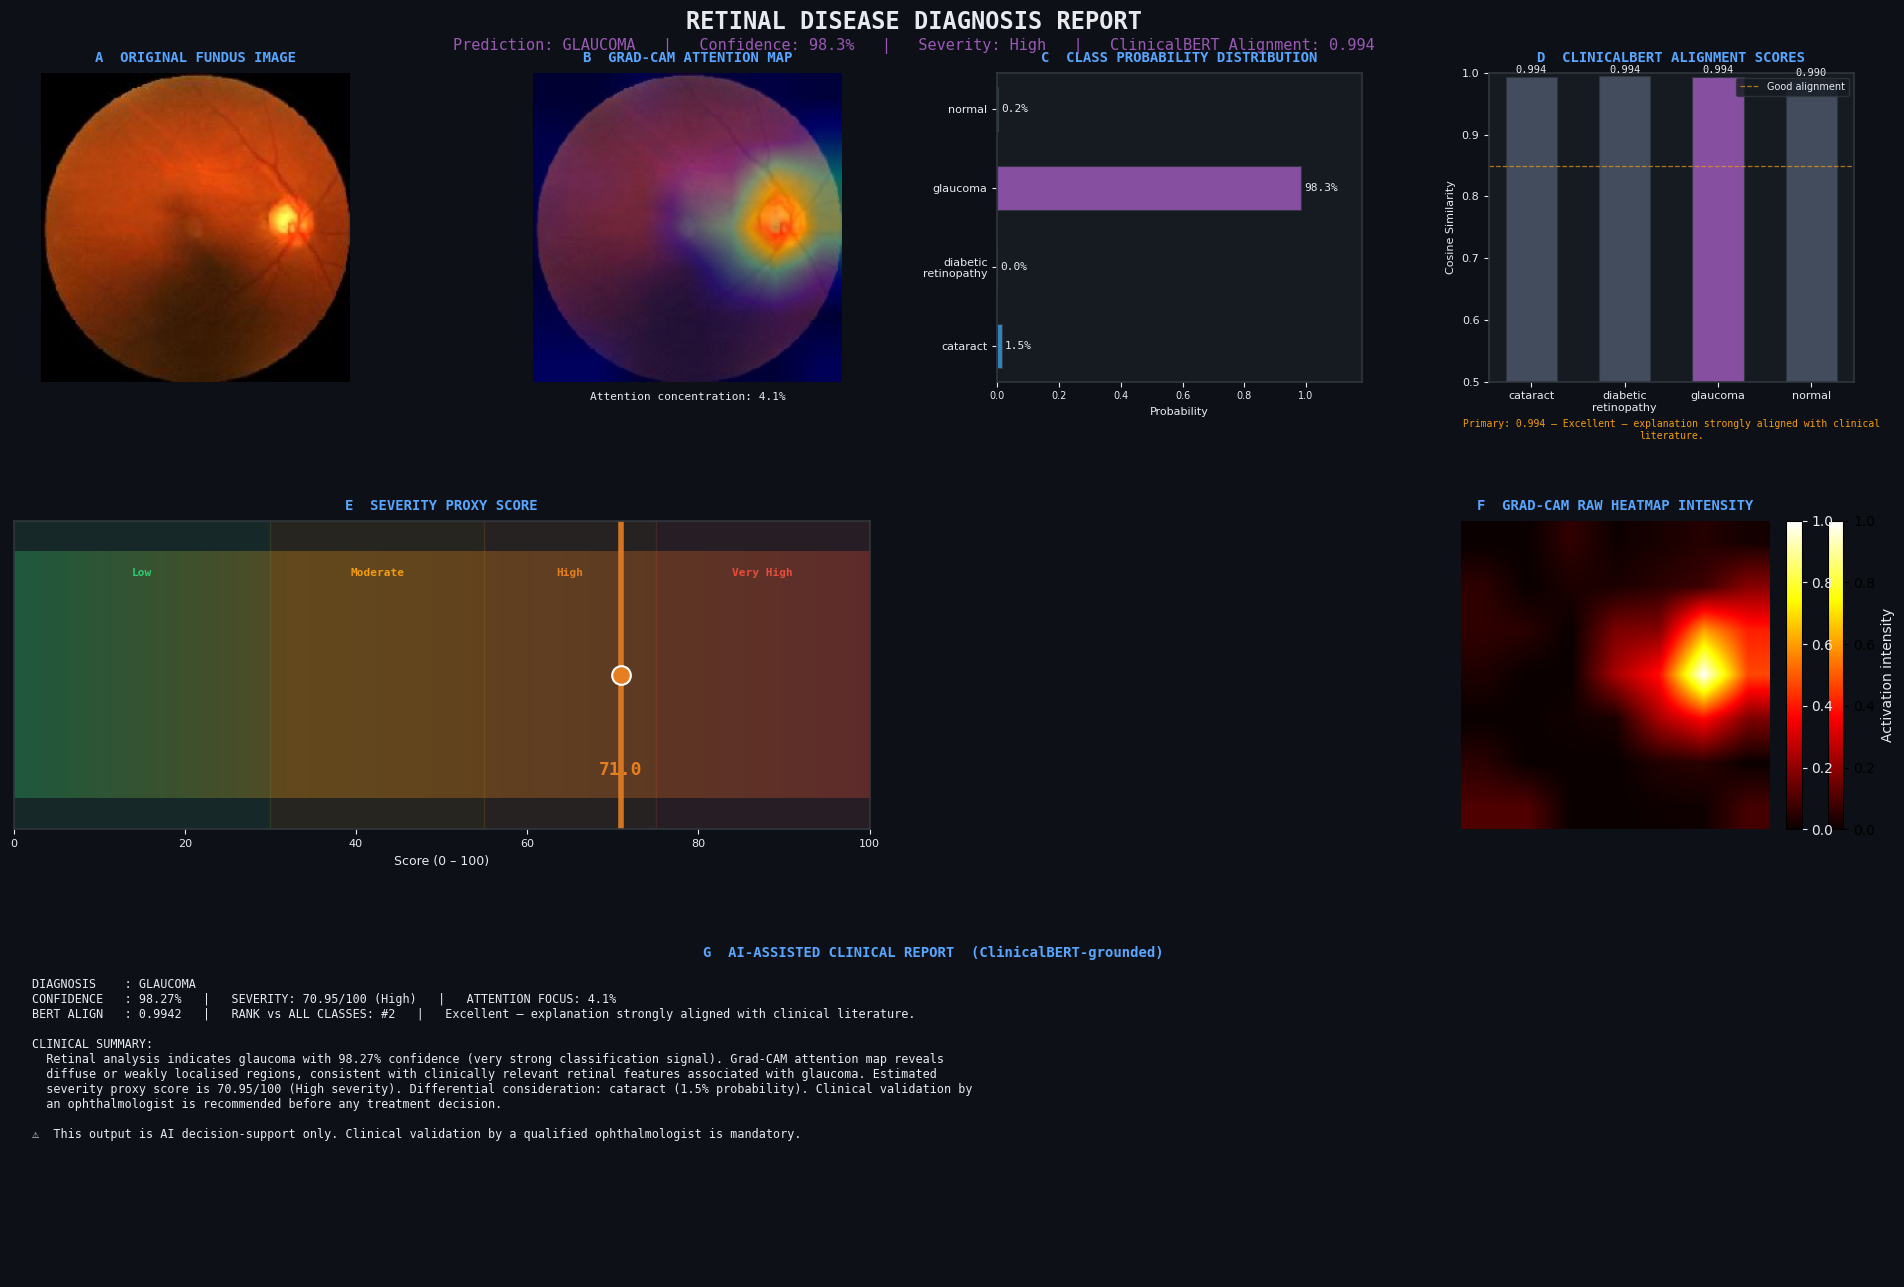

Dashboard saved to /content/diagnosis_dashboard.png


In [ ]:
# ── Change this path to any test image ────────────────────────────────────
SAMPLE_IMG = 'drive/MyDrive/Projects/Mini-project/eye-disease-dataset/test_dir/3/_113_8738972.jpg'

print('Running full diagnosis pipeline...')
results = run_full_diagnosis(SAMPLE_IMG)

print(f"\nPrediction  : {results['pred_label']}")
print(f"Confidence  : {results['confidence']*100:.2f}%")
print(f"Severity    : {results['severity_score']}/100 ({results['severity_level']})")
print(f"BERT Align  : {results['alignment']['primary_score']:.4f}")
print(f"All scores  : {results['alignment']['all_scores']}")
print(f"Rank        : #{results['alignment']['rank']} vs all classes")

fig = build_dashboard_figure(results)
plt.savefig('/content/diagnosis_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#0d1117')
plt.show()
print('Dashboard saved to /content/diagnosis_dashboard.png')

## 11. Interactive Gradio Dashboard

In [ ]:
def gradio_pipeline(uploaded_image):
    """
    Gradio handler: receives a PIL image, runs diagnosis pipeline,
    returns dashboard figure + structured text summary.
    """
    temp_path = '/content/temp_gradio_input.jpg'
    uploaded_image.save(temp_path)

    try:
        results = run_full_diagnosis(temp_path)
    except Exception as e:
        err_fig, ax = plt.subplots(facecolor='#0d1117')
        ax.text(0.5, 0.5, f'Error:\n{str(e)}', ha='center', va='center',
                color='red', transform=ax.transAxes)
        ax.axis('off')
        return err_fig, f'Pipeline error: {str(e)}'

    fig = build_dashboard_figure(results)

    # Plain-text summary for the text output box
    align = results['alignment']
    summary = (
        f"{'='*60}\n"
        f"  RETINAL DISEASE AI DIAGNOSIS REPORT\n"
        f"{'='*60}\n"
        f"Predicted Disease  : {results['pred_label'].replace('_',' ').upper()}\n"
        f"Confidence         : {results['confidence']*100:.2f}%\n"
        f"Severity Score     : {results['severity_score']}/100  [{results['severity_level']}]\n"
        f"Attention Focus    : {results['attention_conc']*100:.1f}%\n"
        f"{'─'*60}\n"
        f"ClinicalBERT Alignment Score  : {align['primary_score']:.4f}\n"
        f"Rank vs all classes           : #{align['rank']}\n"
        f"Interpretation                : {align['interpretation']}\n"
        f"All alignment scores          :\n"
        + '\n'.join(f"  {k:25s}: {v:.4f}"
                    for k, v in align['all_scores'].items()) + '\n'
        f"{'─'*60}\n"
        f"Clinical Explanation:\n"
        f"{results['explanation']}\n"
        f"{'='*60}\n"
        f"⚠  AI decision-support only. Consult an ophthalmologist."
    )
    return fig, summary


# ── Build Gradio interface ─────────────────────────────────────────────────
with gr.Blocks(
    title='Retinal Disease Diagnosis',
    theme=gr.themes.Base(
        primary_hue='blue',
        secondary_hue='slate',
        font=gr.themes.GoogleFont('IBM Plex Mono')
    ),
    css="""
    .gradio-container { background: #0d1117 !important; }
    .gr-box { border: 1px solid #30363d !important; background: #161b22 !important; }
    label, .label-wrap { color: #58a6ff !important; font-family: monospace; }
    .gr-button-primary { background: #1f6feb !important; }
    """
) as demo:

    gr.Markdown("""
    # 🔬 Explainable Retinal Disease Diagnosis System
    **ResNet50 + Grad-CAM + ClinicalBERT Semantic Alignment**

    Upload a retinal fundus image to receive:
    - Disease classification & confidence
    - Severity proxy score
    - Grad-CAM visual explanation
    - **ClinicalBERT alignment score** (semantic grounding vs. clinical literature)
    - Structured clinical report

    > ⚠️ *This is a research prototype — not a medical device.*
    """)

    with gr.Row():
        with gr.Column(scale=1):
            img_input = gr.Image(
                type='pil',
                label='Upload Retinal Fundus Image',
                height=300
            )
            run_btn = gr.Button('▶  Run Diagnosis', variant='primary', size='lg')

            gr.Markdown("""
            ### About ClinicalBERT Alignment
            ClinicalBERT is pre-trained on **MIMIC-III** clinical notes.
            The alignment score measures **cosine similarity** between
            the model's explanation and clinical reference descriptions.

            | Score | Interpretation |
            |-------|---------------|
            | > 0.90 | Excellent |
            | 0.80–0.90 | Good |
            | 0.70–0.80 | Fair |
            | < 0.70 | Low |
            """)

        with gr.Column(scale=3):
            dashboard_out = gr.Plot(label='Clinical Dashboard')

    report_out = gr.Textbox(
        label='Structured Clinical Report',
        lines=20,
        max_lines=30
    )

    run_btn.click(
        fn=gradio_pipeline,
        inputs=[img_input],
        outputs=[dashboard_out, report_out]
    )

    gr.Markdown("""
    ---
    *Supported conditions: Cataract · Diabetic Retinopathy · Glaucoma · Normal*
    """)

demo.launch(share=True, debug=False)
print('Gradio app running. Use the public URL above.')

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2f4926c73745964424.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Gradio app running. Use the public URL above.


## 12. Batch Analysis with ClinicalBERT Scores

In [ ]:
# ── Run on multiple images and compare alignment scores ────────────────────
# Update these paths to your test images
BATCH_PATHS = [
    ('drive/MyDrive/Projects/Mini-project/eye-disease-dataset/test_dir/1/2248_right.jpg',   'cataract'),
    ('drive/MyDrive/Projects/Mini-project/eye-disease-dataset/test_dir/2/10009_right.jpeg', 'diabetic_retinopathy'),
    ('drive/MyDrive/Projects/Mini-project/eye-disease-dataset/test_dir/3/_113_8738972.jpg', 'glaucoma'),
    ('drive/MyDrive/Projects/Mini-project/eye-disease-dataset/test_dir/4/2523_left.jpg',    'normal'),
]

records = []
for img_path, true_label in BATCH_PATHS:
    try:
        r = run_full_diagnosis(img_path)
        records.append({
            'image'           : os.path.basename(img_path),
            'true_label'      : true_label,
            'predicted'       : r['pred_label'],
            'correct'         : r['pred_label'] == true_label,
            'confidence'      : round(r['confidence']*100, 2),
            'severity_score'  : r['severity_score'],
            'severity_level'  : r['severity_level'],
            'bert_alignment'  : r['alignment']['primary_score'],
            'bert_rank'       : r['alignment']['rank'],
        })
        print(f"✓ {os.path.basename(img_path)}: {r['pred_label']} "
              f"({r['confidence']*100:.1f}%) | BERT: {r['alignment']['primary_score']:.4f}")
    except Exception as e:
        print(f'✗ {img_path}: {e}')

batch_df = pd.DataFrame(records)
print('\nBatch Results:')
print(batch_df.to_string(index=False))

✓ 2248_right.jpg: cataract (100.0%) | BERT: 0.9936
✓ 10009_right.jpeg: diabetic_retinopathy (99.1%) | BERT: 0.9940
✓ _113_8738972.jpg: glaucoma (98.3%) | BERT: 0.9942
✓ 2523_left.jpg: normal (99.7%) | BERT: 0.9900

Batch Results:
           image           true_label            predicted  correct  confidence  severity_score severity_level  bert_alignment  bert_rank
  2248_right.jpg             cataract             cataract     True       99.98           66.35           High          0.9936          3
10009_right.jpeg diabetic_retinopathy diabetic_retinopathy     True       99.14           76.43      Very High          0.9940          1
_113_8738972.jpg             glaucoma             glaucoma     True       98.27           70.95           High          0.9942          2
   2523_left.jpg               normal               normal     True       99.68           55.29           High          0.9900          4


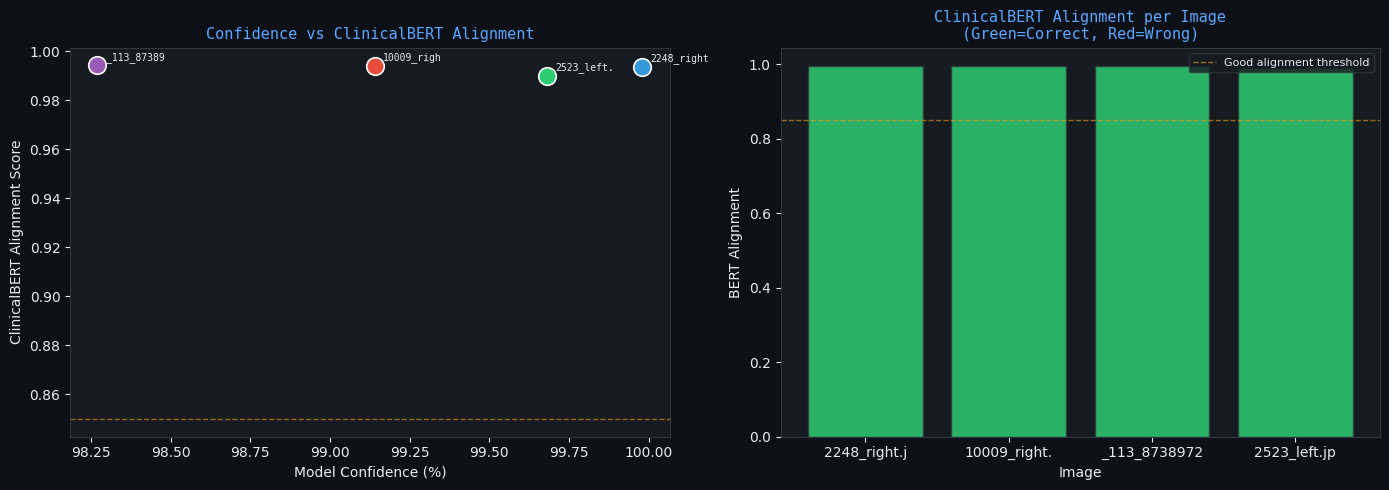

Analysis plot saved.


In [ ]:
# ── Plot: Confidence vs BERT Alignment ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='#0d1117')

for ax in axes:
    ax.set_facecolor('#161b22')
    for sp in ax.spines.values():
        sp.set_edgecolor('#30363d')

TEXT_COLOR  = '#e8eaf0'
ACCENT      = '#58a6ff'

# Scatter: Confidence vs Alignment
scatter_colors = [
    DISEASE_COLORS.get(r, '#58a6ff') for r in batch_df['predicted']
]
markers = ['o' if c else 'X' for c in batch_df['correct']]

for i, row in batch_df.iterrows():
    axes[0].scatter(
        row['confidence'], row['bert_alignment'],
        color=scatter_colors[i],
        marker='o' if row['correct'] else 'X',
        s=160, zorder=5, edgecolors='white', linewidths=1.2,
        label=row['predicted'].replace('_',' ')
    )
    axes[0].annotate(row['image'][:10],
                     (row['confidence'], row['bert_alignment']),
                     textcoords='offset points', xytext=(6, 4),
                     fontsize=7, color=TEXT_COLOR, fontfamily='monospace')

axes[0].axhline(0.85, color='#f39c12', linestyle='--', alpha=0.6, linewidth=1)
axes[0].set_xlabel('Model Confidence (%)', color=TEXT_COLOR)
axes[0].set_ylabel('ClinicalBERT Alignment Score', color=TEXT_COLOR)
axes[0].set_title('Confidence vs ClinicalBERT Alignment', color=ACCENT,
                  fontfamily='monospace', fontsize=11)
axes[0].tick_params(colors=TEXT_COLOR)

# Bar: BERT alignment per image
bar_colors = ['#2ecc71' if c else '#e74c3c' for c in batch_df['correct']]
axes[1].bar(batch_df['image'].str[:12], batch_df['bert_alignment'],
            color=bar_colors, alpha=0.85, edgecolor='#30363d')
axes[1].axhline(0.85, color='#f39c12', linestyle='--', alpha=0.6,
                linewidth=1, label='Good alignment threshold')
axes[1].set_xlabel('Image', color=TEXT_COLOR)
axes[1].set_ylabel('BERT Alignment', color=TEXT_COLOR)
axes[1].set_title('ClinicalBERT Alignment per Image\n(Green=Correct, Red=Wrong)',
                  color=ACCENT, fontfamily='monospace', fontsize=11)
axes[1].tick_params(colors=TEXT_COLOR, axis='both')
axes[1].legend(fontsize=8, facecolor='#161b22', labelcolor=TEXT_COLOR,
               edgecolor='#30363d')

plt.tight_layout()
plt.savefig('/content/bert_alignment_analysis.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Analysis plot saved.')

In [ ]:
# ── Save batch results ─────────────────────────────────────────────────────
save_path = 'drive/MyDrive/Projects/Mini-project/reports/clinicalbert_batch_results.csv'
batch_df.to_csv(save_path, index=False)
print(f'Saved batch results to {save_path}')
print(f'\nMean BERT alignment : {batch_df["bert_alignment"].mean():.4f}')
print(f'Accuracy            : {batch_df["correct"].mean()*100:.1f}%')

Saved batch results to drive/MyDrive/Projects/Mini-project/reports/clinicalbert_batch_results.csv

Mean BERT alignment : 0.9929
Accuracy            : 100.0%
